1370
1370
                precision    recall  f1-score   support

       Negativ       0.98      0.82      0.89      7058
       Positiv       0.59      0.96      0.73       528
Lätt avvikande       0.10      0.29      0.14       286
   Oligoklonal       0.11      0.31      0.16       176

     micro avg       0.79      0.80      0.79      8048
     macro avg       0.44      0.59      0.48      8048
  weighted avg       0.91      0.80      0.84      8048



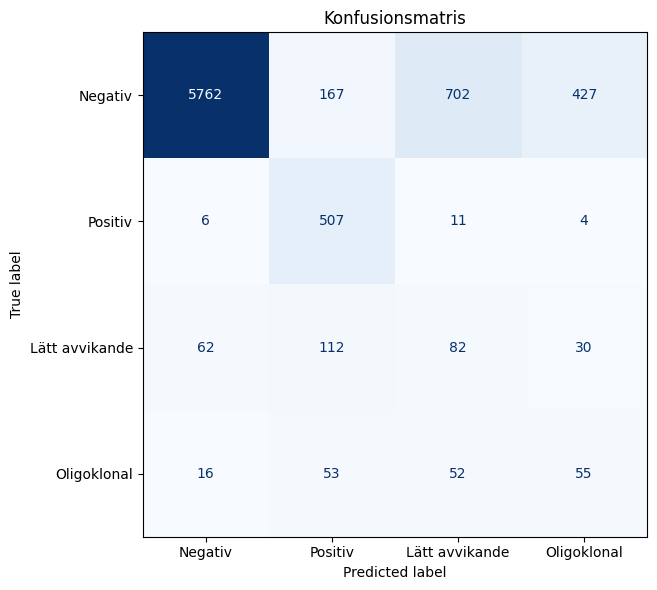

Antalet fall där fria lätta ändrar bedömningen: 19
Nya positiva till följd av fria lätta kedjor: 17
Nya negativa till följd av fria lätta kedjor: 2
Accuracy:  79.10%
FN-rate:   0.61%  (farliga missade fall)
FP-rate:   18.36%  (onödiga larm)
Sensitivitet:   98.86%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   81.64%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
Enbart M-komponent eller ej:



              precision    recall  f1-score   support

     Negativ       1.00      0.95      0.97      7571
     Positiv       0.59      0.96      0.73       528

    accuracy                           0.95      8099
   macro avg       0.79      0.96      0.85      8099
weighted avg       0.97      0.95      0.96      8099

[[7219  352]
 [  21  507]]
Antalet fall där fria lätta ändrar bedömningen: 19
Nya positiva till följd av fria lätta kedjor: 17
Nya negativa till följd av fria lätta kedjor: 2
AUC: 0.990374455157839
Accuracy:  95.39%
FN-rate:   3.98%  (farlig

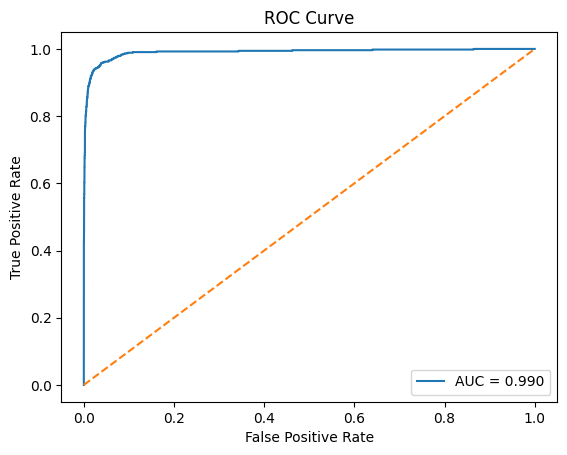

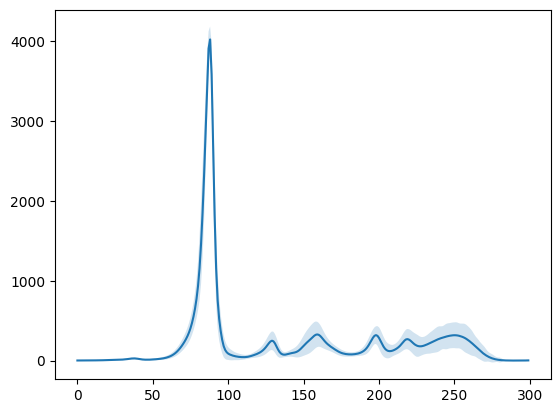

In [1]:
import duckdb
from functions.analyte import ANALYTES
from networks.cnn_dilated_convolutions import CNNModel
from functions.evaluation import evaluate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functions.free_light_chains import predict_using_free_light_chains
from functions.full_model import predict
from functions.evaluation import evaluate_all_classes

con = duckdb.connect('../capillary.db')

df = con.execute(""" 
                 SELECT row_id, age, gender, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm,s_kappa,s_lambda,s_kl_kvot,u_albumin_krea,u_igg_krea,u_kappa_krea,u_lambda_krea,u_hc_krea,u_kappa,u_lambda,u_kreatinin, label, set, interpretation,protein_comments
                 FROM protein_data 
                 WHERE observation_nr = 1
                 AND set = 'test'
                 """).df()



con.close()


protein_cols = [a.col for a in ANALYTES[:8]]  # bara de 8 första
df = df.dropna(subset=protein_cols)

only_m_component_or_not = df.copy()
only_m_component_or_not.loc[~df['label'].isin([0,1]),'label'] = 0

df = predict(df,threshold=0.2,proportion=70)

only_m_component_or_not = predict(only_m_component_or_not,threshold=0.2,proportion=70)
rows = evaluate_all_classes(df)

print("Enbart M-komponent eller ej:\n\n\n")
only_m_component_or_not.loc[~df['final_prediction'].isin([0,1]),'final_prediction'] = 0
rows = evaluate(only_m_component_or_not)

stats = pd.DataFrame()
x_avg = np.concatenate([
    np.stack(df['value'].values).mean(axis=0),   # (300,)
    np.stack(df['fractions'].values).mean(axis=0),                      # (6,)
    np.stack(df['boundaries'].values).mean(axis=0),                      # (12,)
    df[protein_cols].mean(axis=0)                        # (8,)
]) 

x_std = np.concatenate([
    np.stack(df['value'].values).std(axis=0),   # (300,)
    np.stack(df['fractions'].values).std(axis=0),                      # (6,)
    np.stack(df['boundaries'].values).std(axis=0),                      # (12,)
    df[protein_cols].std(axis=0)                        # (8,)
]) 

stats['avg'] = x_avg
stats['std'] = x_std
stats.to_csv('statistics_overview.csv')
plt.figure()
plt.plot(range(300),stats['avg'][0:300])
plt.fill_between(range(300),x_avg[0:300]-x_std[0:300],x_avg[0:300]+x_std[0:300],alpha=0.2)
plt.show()


P(lätt avvikande)=30.72%
P(oligoklonalt)=29.61%


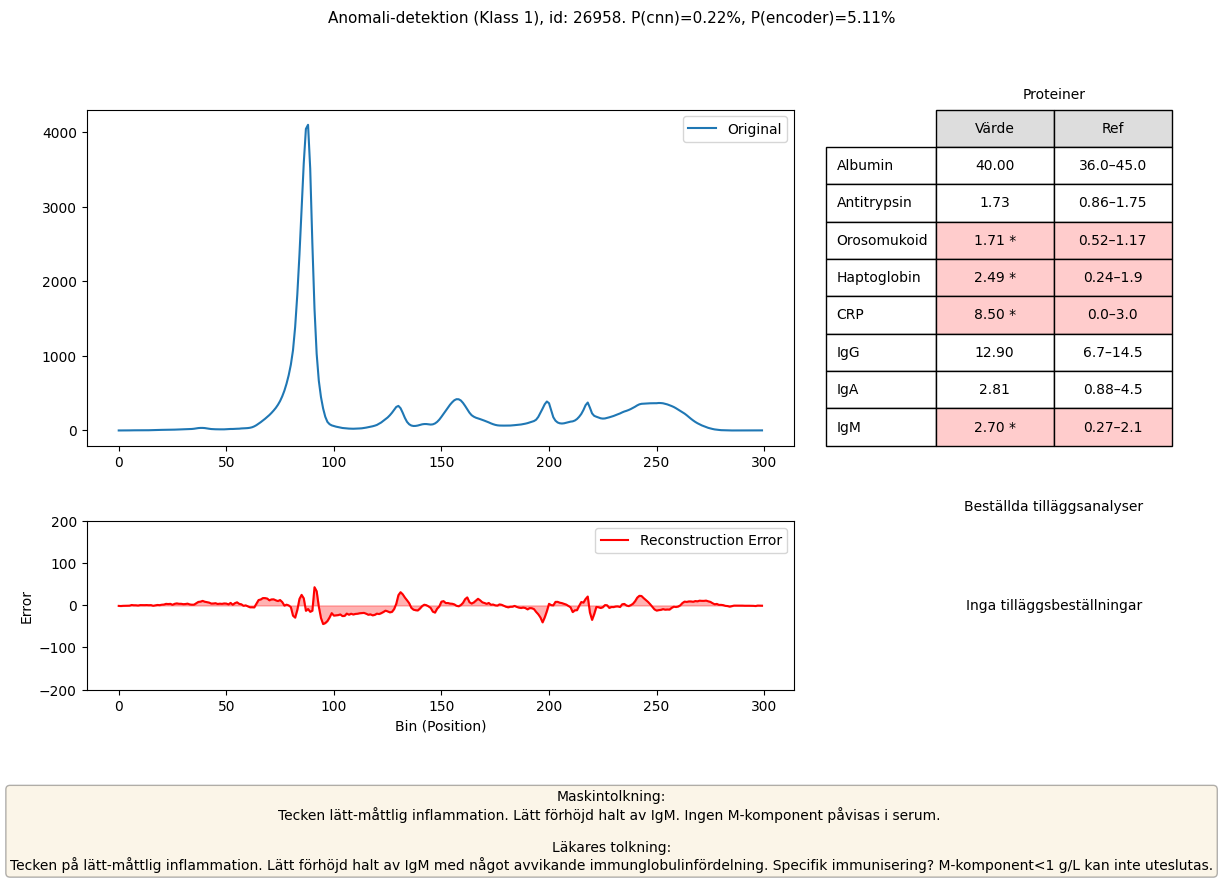

In [ ]:
import importlib
import functions.full_model as full_model
importlib.reload(full_model)
from functions.full_model import interpret
import random


#df['prediction'] = ((df['cnn_probability'] > 0.15) | (df['proportion_gamma_region'] > 0.5)).astype(int)

#rows = processed_rows[processed_rows['proportion_gamma_region'] > 0.9].sort_values('proportion_gamma_region',ascending=False)
#row = df[ (df['final_prediction'] == 1) & (df['label'] == 0)].iloc[12]
#row = df[df['label'] == 2].sample(1).iloc[0]
row = df[(df['label'] == 1) & (df['final_prediction'] == 0)].iloc[2]
row = only_m_component_or_not[(only_m_component_or_not['label'] == 1) & ~only_m_component_or_not['final_prediction'].isin([1,2,4])].iloc[5]
result = interpret(row.to_dict())

# print(f"Max:    {aucs.max():.1f}")
# print(f"Mean:   {aucs.mean():.1f}")
# print(f"Median: {np.median(aucs):.1f}")

# print(f"95e percentilen {np.percentile(aucs, 95)}")